# Visualización de Datos — Proceso de Admisión DEMRE 2026

**Issue #12:** Extraer los datos del ETL y visualizarlos con 5 gráficos que cuenten historias.

**Herramientas:** Plotly · Matplotlib · Seaborn

**Fuente:** `data/processed/ArchivoC_2026_limpia.parquet` + `ArchivoD_Adm2026REG.csv`


In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings, os
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
os.makedirs('../reports/figures', exist_ok=True)

# ─── Datos ──────────────────────────────────────────────────────────────────
df_c = pl.read_parquet('../data/processed/ArchivoC_2026_limpia.parquet')

df_d = (pl.read_csv('../data/raw/ArchivoD_Adm2026REG.csv',
         separator=';', encoding='utf8-lossy',
         columns=['ID_aux','ORDEN_PREF','ESTADO_PREF','PTJE_PREF'])
        .filter(pl.col('ORDEN_PREF') == 1)
        .with_columns([
            (pl.col('ESTADO_PREF') == 24).cast(pl.Int32).alias('ACCESO_1PREF'),
            pl.col('PTJE_PREF').str.replace_all(',','.').cast(pl.Float64, strict=False)
        ]))

df = df_c.join(df_d, on='ID_aux', how='inner').to_pandas()

# Mapas de etiquetas
DEP_MAP = {'1':'Municipal','2':'Part. Subvencionado','3':'Part. Pagado','4':'CORP'}
REG_MAP = {
    '1':'Tarapacá','2':'Antofagasta','3':'Atacama','4':'Coquimbo','5':'Valparaíso',
    '6':'O´Higgins','7':'Maule','8':'Biobío','9':'Araucanía','10':'Los Lagos',
    '11':'Aysén','12':'Magallanes','13':'Metropolitana','14':'Los Ríos',
    '15':'Arica y Parinacota','16':'Ñuble'
}

df['dependencia'] = df['GRUPO_DEPENDENCIA'].map(DEP_MAP).fillna('Otro')
df['region']      = df['CODIGO_REGION'].map(REG_MAP).fillna('Desconocida')

print(f'Dataset total: {df.shape[0]:,} postulantes')
print(f'Con acceso a 1ª preferencia: {df.ACCESO_1PREF.sum():,} ({df.ACCESO_1PREF.mean()*100:.1f}%)')


Dataset total: 226,577 postulantes
Con acceso a 1ª preferencia: 75,358 (33.3%)


## Gráfico 1 — La brecha educacional: puntajes según tipo de colegio

¿Existe diferencia real en los puntajes PAES entre estudiantes de distintos tipos de establecimiento?
Este gráfico responde esa pregunta comparando la distribución del puntaje NEM para cada tipo de colegio,
separando a quienes accedieron de quienes no.


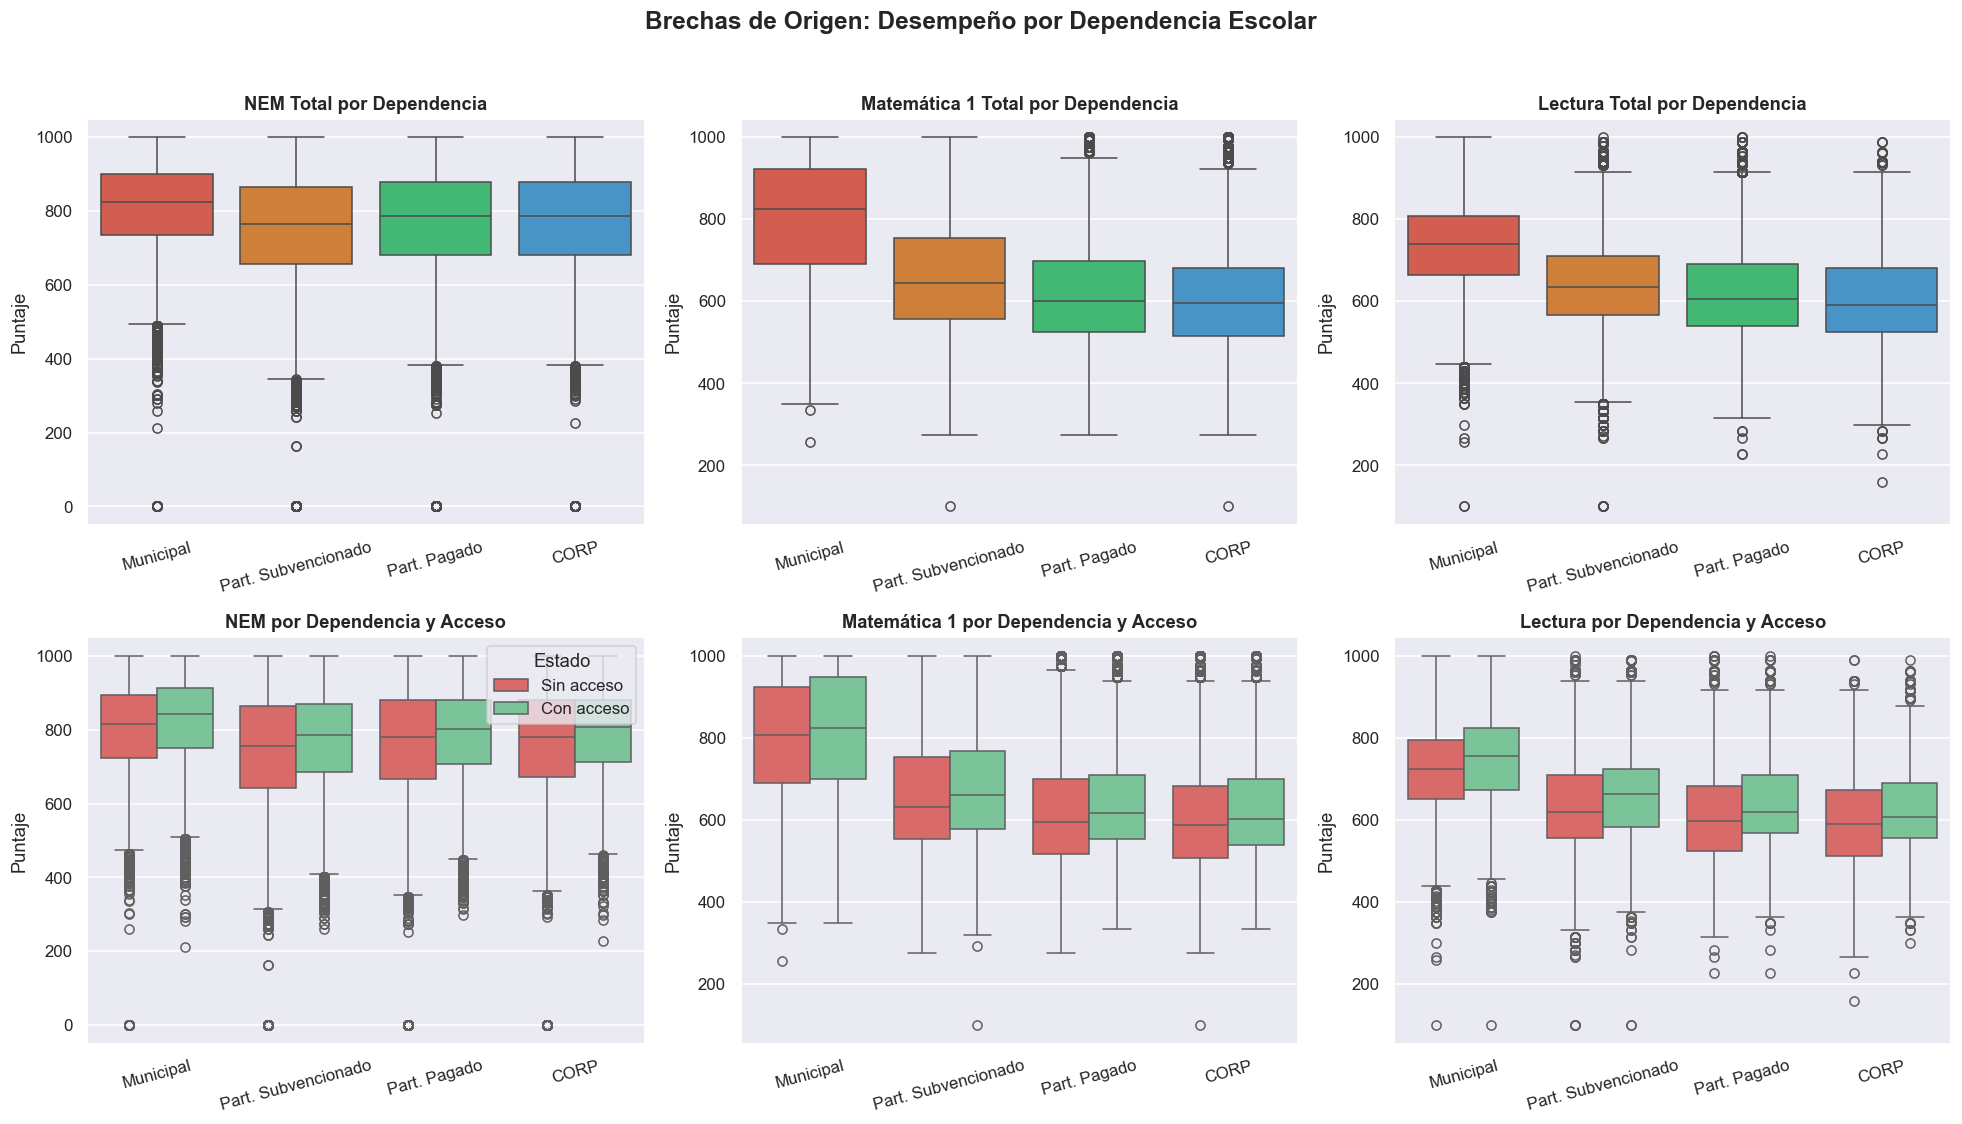

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)

DEPS   = ['Municipal','Part. Subvencionado','Part. Pagado','CORP']
COLS   = ['#e74c3c','#e67e22','#2ecc71','#3498db']
df_dep = df[df['dependencia'].isin(DEPS)].copy()

features = [('PTJE_NEM', 'NEM'), ('MATE1_REG_ACTUAL', 'Matemática 1'), ('CLEC_REG_ACTUAL', 'Lectura')]

for i, (col, title) in enumerate(features):
    sns.boxplot(data=df_dep, x='dependencia', y=col, order=DEPS, palette=COLS, ax=axes[0, i])
    axes[0, i].set_title(f'{title} Total por Dependencia', fontweight='bold')
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('Puntaje')
    axes[0, i].tick_params(axis='x', rotation=15)

for i, (col, title) in enumerate(features):
    sns.boxplot(data=df_dep, x='dependencia', y=col, hue='ACCESO_1PREF', order=DEPS,
                palette=['#eb5757', '#6fcf97'], ax=axes[1, i])
    axes[1, i].set_title(f'{title} por Dependencia y Acceso', fontweight='bold')
    axes[1, i].set_xlabel('')
    axes[1, i].set_ylabel('Puntaje')
    axes[1, i].tick_params(axis='x', rotation=15)
    handles, labels = axes[1, i].get_legend_handles_labels()
    if i == 0:
        axes[1, i].legend(handles, ['Sin acceso', 'Con acceso'], title='Estado')
    else:
        axes[1, i].get_legend().remove()

plt.suptitle('Brechas de Origen: Desempeño por Dependencia Escolar', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/g1_brecha_dependencia.png', bbox_inches='tight', dpi=110)
plt.show()


### Alternativas para G1 (Brechas por Dependencia)

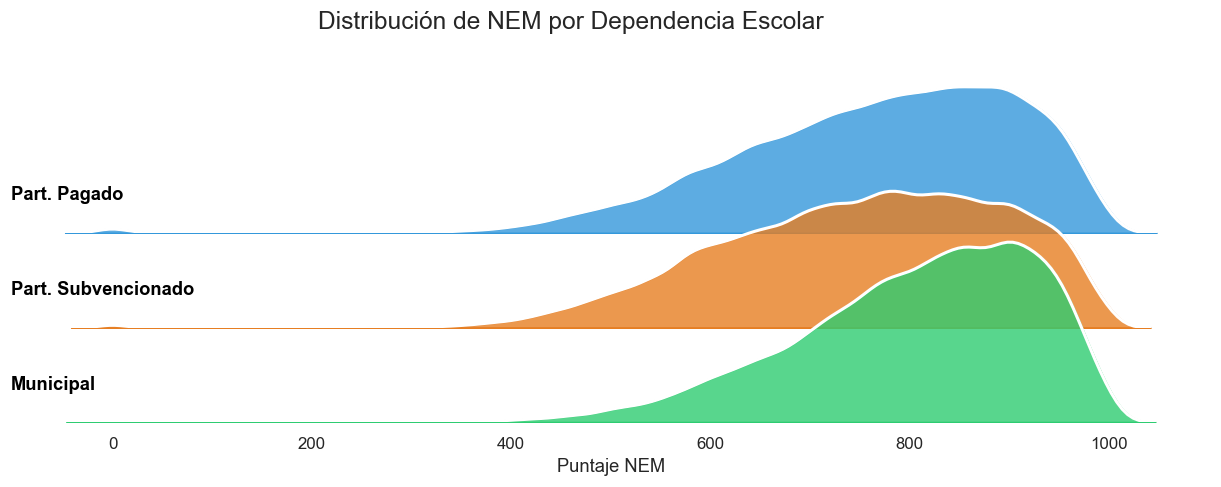

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl

# Filtrar dependencias principales y convertir a pandas para seaborn
df_plot = df[df['dependencia'].isin(['Municipal', 'Part. Subvencionado', 'Part. Pagado'])]

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
g = sns.FacetGrid(df_plot, row="dependencia", hue="dependencia", aspect=8, height=1.5, 
                  palette=["#3498db", "#e67e22", "#2ecc71"])

# Dibujar las crestas (densidades solapadas)
g.map_dataframe(sns.kdeplot, x="PTJE_NEM", fill=True, alpha=0.8, linewidth=1.5)
g.map_dataframe(sns.kdeplot, x="PTJE_NEM", color="white", lw=2) # borde blanco

# Añadir nombres de colegios al costado izquierdo
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color="black", 
            ha="left", va="center", transform=ax.transAxes, fontsize=12)
g.map(label, "PTJE_NEM")

# Ajuste visual para el solapamiento "efecto montaña"
g.fig.subplots_adjust(hspace=-0.5) 
g.set_titles("")
g.set(yticks=[], ylabel="", xlabel="Puntaje NEM")
g.despine(bottom=True, left=True)
plt.suptitle('Distribución de NEM por Dependencia Escolar', fontsize=16, y=0.98)
plt.show()



In [4]:
import plotly.express as px

# Filtrar y agrupar usando Polars
df_bar = df[df['dependencia'].isin(['Municipal', 'Part. Subvencionado', 'Part. Pagado'])]
stats = df_bar.groupby(['dependencia', 'ACCESO_1PREF']).size().reset_index(name='count')

# Calcular el porcentaje de destino
stats['%'] = stats.groupby('dependencia')['count'].transform(lambda x: x / x.sum() * 100)
stats['Estado'] = stats['ACCESO_1PREF'].map({0: 'Sin acceso', 1: 'Con acceso'})

fig = px.bar(stats, x='%', y='dependencia', color='Estado', orientation='h',
             color_discrete_map={'Sin acceso': '#eb5757', 'Con acceso': '#6fcf97'},
             text_auto='.1f', title='Destino final del alumno por Tipo de Colegio')

fig.update_layout(barmode='stack', xaxis_title='Porcentaje de Alumnos (%)', yaxis_title='', 
                  template='plotly_dark', paper_bgcolor='#0f1117', plot_bgcolor='#1a1f2e')
fig.show()



---

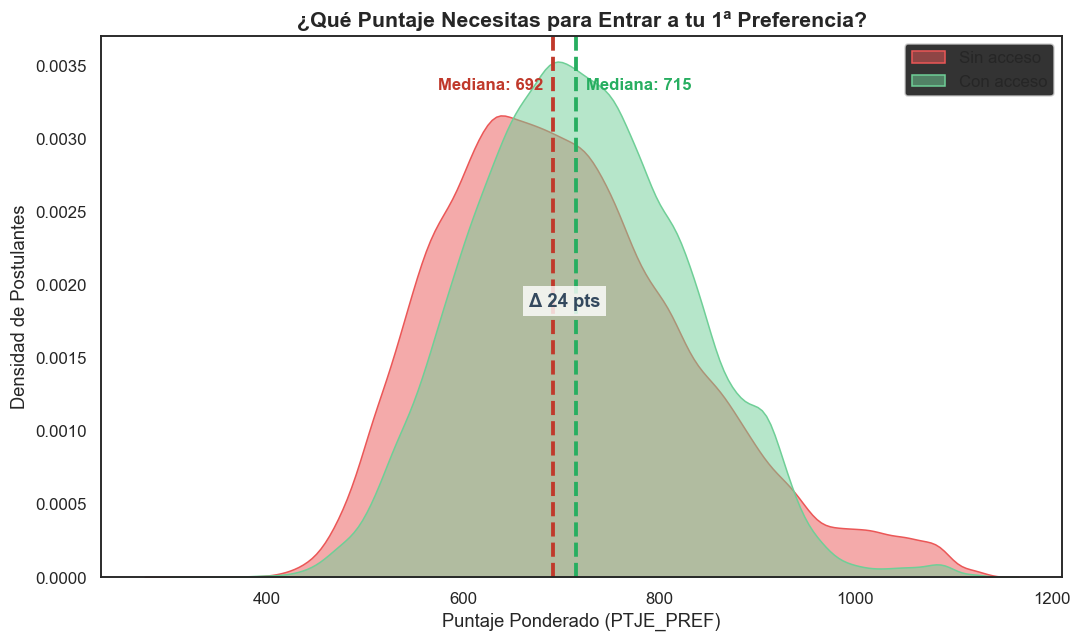

Mediana sin acceso: 692 pts  |  Mediana con acceso: 715 pts
Diferencia en medianas: 24 puntos


In [5]:
df_pref = df.dropna(subset=['PTJE_PREF'])

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_pref[df_pref['ACCESO_1PREF']==0], x='PTJE_PREF', fill=True, color='#eb5757', label='Sin acceso', alpha=0.5)
sns.kdeplot(data=df_pref[df_pref['ACCESO_1PREF']==1], x='PTJE_PREF', fill=True, color='#6fcf97', label='Con acceso', alpha=0.5)

p50_sin = df_pref[df_pref['ACCESO_1PREF']==0]['PTJE_PREF'].median()
p50_con = df_pref[df_pref['ACCESO_1PREF']==1]['PTJE_PREF'].median()

plt.axvline(p50_sin, color='#c0392b', linestyle='--', linewidth=2.5)
plt.axvline(p50_con, color='#27ae60', linestyle='--', linewidth=2.5)

ylim = plt.gca().get_ylim()
plt.text(p50_sin - 10, ylim[1]*0.9, f'Mediana: {p50_sin:.0f}', color='#c0392b', ha='right', fontweight='bold', fontsize=11)
plt.text(p50_con + 10, ylim[1]*0.9, f'Mediana: {p50_con:.0f}', color='#27ae60', ha='left', fontweight='bold', fontsize=11)
plt.text((p50_sin + p50_con)/2, ylim[1]*0.5, f'Δ {p50_con - p50_sin:.0f} pts', color='#34495e', ha='center', fontweight='bold', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.title('¿Qué Puntaje Necesitas para Entrar a tu 1ª Preferencia?', fontsize=14, fontweight='bold')
plt.xlabel('Puntaje Ponderado (PTJE_PREF)', fontsize=12)
plt.ylabel('Densidad de Postulantes', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../reports/figures/g2_umbral_acceso.png', bbox_inches='tight', dpi=110)
plt.show()

print(f'Mediana sin acceso: {p50_sin:.0f} pts  |  Mediana con acceso: {p50_con:.0f} pts')
print(f'Diferencia en medianas: {p50_con - p50_sin:.0f} puntos')


### Alternativas para G2 (Umbral de Acceso)

In [6]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

df_pref = df.dropna(subset=['PTJE_PREF']).copy()

# Agrupar en tramos de 25 puntos
bins = np.arange(400, 1050, 25)
df_pref['rango'] = pd.cut(df_pref['PTJE_PREF'], bins=bins, labels=bins[:-1])

sin_acceso = df_pref[df_pref['ACCESO_1PREF'] == 0].groupby('rango').size()
con_acceso = df_pref[df_pref['ACCESO_1PREF'] == 1].groupby('rango').size()

y_vals = sin_acceso.index.astype(str) + ' pts'

fig = go.Figure()
# Hacia la izquierda (valores negativos para crear la pirámide)
fig.add_trace(go.Bar(y=y_vals, x=-sin_acceso.values, name='Sin acceso', orientation='h', marker_color='#eb5757'))
# Hacia la derecha
fig.add_trace(go.Bar(y=y_vals, x=con_acceso.values, name='Con acceso', orientation='h', marker_color='#6fcf97'))

fig.update_layout(
    title='Pirámide de Selección: ¿Dónde está el umbral de corte real?',
    barmode='overlay', bargap=0.1,
    xaxis=dict(tickvals=[-20000, -10000, 0, 10000, 20000], ticktext=['20k', '10k', '0', '10k', '20k'], title='Volumen de Estudiantes'),
    yaxis_title='Puntaje Ponderado Obtenido',
    template='plotly_dark', paper_bgcolor='#0f1117', plot_bgcolor='#1a1f2e'
)
fig.show()



In [7]:
import plotly.express as px

total_inscritos = len(df)
postularon = len(df.dropna(subset=['PTJE_PREF']))
seleccionados = len(df[df['ACCESO_1PREF'] == 1])

data = dict(
    etapa=['Total PAES', 'Postularon a 1ª Preferencia', 'Accedieron a 1ª Preferencia'],
    cantidad=[total_inscritos, postularon, seleccionados]
)

fig = px.funnel(data, x='cantidad', y='etapa', title='El Embudo de Admisión 2026',
                color_discrete_sequence=['#3498db'])
fig.update_layout(template='plotly_dark', paper_bgcolor='#0f1117', plot_bgcolor='#1a1f2e')
fig.show()



---

In [8]:
reg_stats = (df[df['region'] != 'Desconocida']
             .groupby('region')['ACCESO_1PREF']
             .agg(['sum','count','mean'])
             .rename(columns={'sum':'accedieron','count':'total','mean':'tasa'})
             .reset_index()
             .sort_values('tasa', ascending=True))

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Postulantes por Región','Tasa de Acceso por Región (%)'),
    horizontal_spacing=0.12)

cmap = px.colors.sample_colorscale('Viridis', reg_stats['tasa'])

fig.add_trace(go.Bar(
    y=reg_stats['region'], x=reg_stats['total'],
    orientation='h', name='Postulantes',
    marker_color=cmap, text=reg_stats['total'].apply(lambda x: f'{x:,}'),
    textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    y=reg_stats['region'], x=(reg_stats['tasa']*100).round(1),
    orientation='h', name='Tasa (%)',
    marker_color=cmap,
    text=(reg_stats['tasa']*100).round(1).astype(str) + '%',
    textposition='outside'
), row=1, col=2)

fig.update_layout(
    title_text='El Talento No Tiene Región: Distribución Geográfica del Acceso 2026',
    title_font_size=15, showlegend=False,
    template='plotly_dark', paper_bgcolor='#0f1117', plot_bgcolor='#1a1f2e',
    height=600, width=1000
)
fig.update_xaxes(row=1, col=2, range=[0, reg_stats['tasa'].max()*120])
fig.write_image('../reports/figures/g3_mapa_regional.png')
fig.show()



---

In [9]:
promedios = {}
tests = ['PTJE_NEM','PTJE_RANKING','CLEC_REG_ACTUAL','MATE1_REG_ACTUAL',
         'HCSOC_REG_ACTUAL','CIEN_REG_ACTUAL']
labels = ['NEM','Ranking','Lectura','Matemática 1','Historia','Ciencias']

for acc in [0, 1]:
    sub = df[df['ACCESO_1PREF']==acc]
    promedios[acc] = [sub[t].dropna().mean() / 1000 for t in tests]

cats  = labels + [labels[0]]
vals0 = promedios[0] + [promedios[0][0]]
vals1 = promedios[1] + [promedios[1][0]]

fig = go.Figure()
fig.add_trace(go.Scatterpolar(
    r=vals0, theta=cats, fill='toself', name='Sin acceso',
    fillcolor='rgba(235,87,87,0.20)',
    line=dict(color='#eb5757', width=2.5)
))
fig.add_trace(go.Scatterpolar(
    r=vals1, theta=cats, fill='toself', name='Con acceso',
    fillcolor='rgba(111,207,151,0.20)',
    line=dict(color='#6fcf97', width=2.5)
))

for i, (label, v0, v1) in enumerate(zip(labels, promedios[0], promedios[1])):
    print(f'{label:20s}: sin acceso={v0*1000:.0f}  con acceso={v1*1000:.0f}  Δ={abs(v1-v0)*1000:.0f} pts')

fig.update_layout(
    polar=dict(
        bgcolor='rgba(26,31,46,0.9)',
        radialaxis=dict(visible=True, range=[0,1],
                        gridcolor='#2d3250', tickfont=dict(color='#8892b0'),
                        tickvals=[0.3,0.5,0.7,0.9]),
        angularaxis=dict(gridcolor='#2d3250', tickfont=dict(color='#ccd6f6', size=12))
    ),
    title='ADN Académico: El Perfil Promedio del Estudiante que Accede vs el que No',
    title_font_size=14,
    template='plotly_dark', paper_bgcolor='#0f1117',
    legend=dict(x=0.8, y=1.1), width=700, height=550
)
fig.write_image('../reports/figures/g4_perfil_radar.png')
fig.show()



NEM                 : sin acceso=755  con acceso=781  Δ=26 pts
Ranking             : sin acceso=770  con acceso=798  Δ=27 pts
Lectura             : sin acceso=631  con acceso=665  Δ=34 pts
Matemática 1        : sin acceso=657  con acceso=687  Δ=31 pts
Historia            : sin acceso=512  con acceso=557  Δ=45 pts
Ciencias            : sin acceso=487  con acceso=503  Δ=16 pts


---

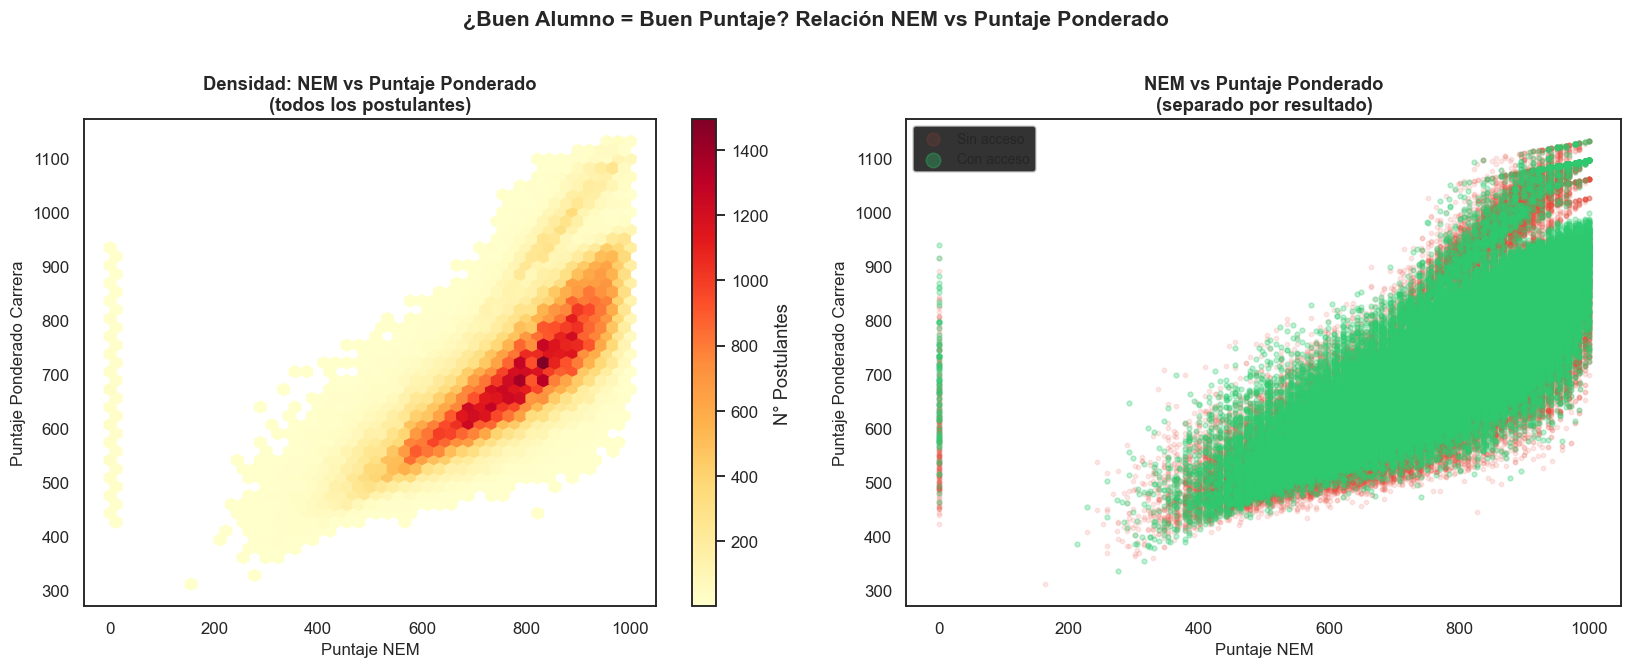

Corr. Pearson NEM vs PTJE_PREF: 0.760


In [10]:
df_plot = df.dropna(subset=['PTJE_NEM','PTJE_PREF']).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel izquierdo: hexbin densidad total
hb = axes[0].hexbin(df_plot['PTJE_NEM'], df_plot['PTJE_PREF'],
                    gridsize=45, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=axes[0], label='N° Postulantes')
axes[0].set_xlabel('Puntaje NEM', fontsize=11)
axes[0].set_ylabel('Puntaje Ponderado Carrera', fontsize=11)
axes[0].set_title('Densidad: NEM vs Puntaje Ponderado\n(todos los postulantes)', fontweight='bold')

# Panel derecho: scatter por acceso
for acc, label, color, alpha, size in [
    (0, 'Sin acceso', '#e74c3c', 0.12, 8),
    (1, 'Con acceso', '#2ecc71', 0.30, 10)
]:
    sub = df_plot[df_plot['ACCESO_1PREF']==acc]
    axes[1].scatter(sub['PTJE_NEM'], sub['PTJE_PREF'],
                    c=color, alpha=alpha, s=size, label=label, rasterized=True)

axes[1].set_xlabel('Puntaje NEM', fontsize=11)
axes[1].set_ylabel('Puntaje Ponderado Carrera', fontsize=11)
axes[1].set_title('NEM vs Puntaje Ponderado\n(separado por resultado)', fontweight='bold')
axes[1].legend(markerscale=3, fontsize=9)

plt.suptitle('¿Buen Alumno = Buen Puntaje? Relación NEM vs Puntaje Ponderado',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/g5_nem_ponderado.png', bbox_inches='tight', dpi=110)
plt.show()
print(f'Corr. Pearson NEM vs PTJE_PREF: {df_plot["PTJE_NEM"].corr(df_plot["PTJE_PREF"]):.3f}')



### Nuevas Alternativas Conceptuales para G6

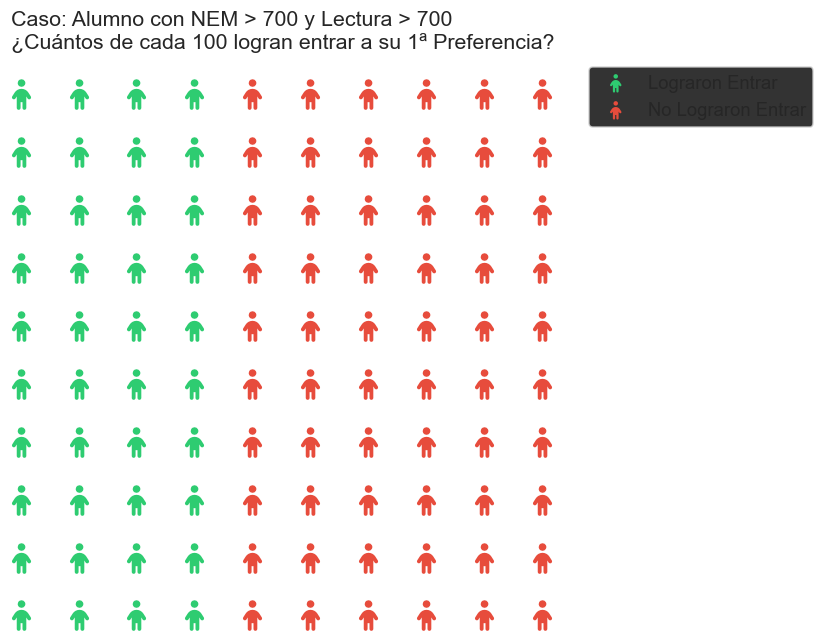

In [13]:
import matplotlib.pyplot as plt
from pywaffle import Waffle

# Escenario: Estudiante sobresaliente (NEM > 700 y Lectura > 700)
df_waf = df.dropna(subset=['PTJE_NEM', 'CLEC_REG_ACTUAL']).copy()
perfil = df_waf[(df_waf['PTJE_NEM'] > 700) & (df_waf['CLEC_REG_ACTUAL'] > 700)]
tasa_exito = int(perfil['ACCESO_1PREF'].mean() * 100)

data = {'Lograron Entrar': tasa_exito, 'No Lograron Entrar': 100 - tasa_exito}

fig = plt.figure(
    FigureClass=Waffle,
    rows=10, columns=10,
    values=data,
    colors=["#2ecc71", "#e74c3c"],
    title={'label': 'Caso: Alumno con NEM > 700 y Lectura > 700\n¿Cuántos de cada 100 logran entrar a su 1ª Preferencia?', 
           'loc': 'left', 'fontsize': 14},
    legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1), 'fontsize': 12},
    figsize=(8, 6),
    icons='child', icon_size=20, icon_legend=True  # Usa iconos de personas (basado en FontAwesome)
)
plt.show()



In [38]:
import plotly.express as px
import pandas as pd
import requests

# 1. Descargar el mapa de Chile (GeoJSON) desde un repositorio público confiable
url_geojson = "https://raw.githubusercontent.com/caracena/chile-geojson/master/regiones.json"
chile_geojson = requests.get(url_geojson).json()

# Estandarizar el código de región a string en el geojson para cruzarlo sin problemas
for feature in chile_geojson['features']:
    feature['properties']['codregion'] = str(feature['properties']['codregion'])

# 2. Preparar nuestros datos (agrupados por región)
df_mapa = df[df['CODIGO_REGION'].notna()].copy()
df_mapa['CODIGO_REGION'] = df_mapa['CODIGO_REGION'].astype(str) # Forzamos a string

# Calculamos el volumen y la tasa de acceso por cada código de región
stats_mapa = df_mapa.groupby(['CODIGO_REGION', 'region'])['ACCESO_1PREF'].agg(['count', 'mean']).reset_index()
stats_mapa['Tasa Acceso (%)'] = stats_mapa['mean'] * 100

# 3. Dibujar el mapa Coroplético usando Mapbox
fig = px.choropleth_mapbox(
    stats_mapa, 
    geojson=chile_geojson, 
    locations='CODIGO_REGION',           # Columna en nuestro dataframe
    featureidkey='properties.codregion', # Llave de cruce en el GeoJSON
    color='Tasa Acceso (%)',             # Lo que define el color (rojo=bajo, verde=alto)
    color_continuous_scale="RdYlGn",
    range_color=[25, 45],                # Ajusta los límites según tus datos para contrastar mejor
    mapbox_style="carto-darkmatter",     # Fondo oscuro que resalta el mapa
    zoom=3.2, 
    center={"lat": -38.0, "lon": -72.0}, # Centro de la cámara
    opacity=0.8,
    hover_name='region',
    hover_data={'CODIGO_REGION': False, 'Tasa Acceso (%)': ':.1f', 'count': True},
    labels={'count': 'Total Postulantes', 'Tasa Acceso (%)': 'Tasa (%)'}
)

fig.update_layout(
    title='<b>Mapa del Acceso: Tasa de éxito en 1ª Preferencia por Región</b>',
    margin={"r":0,"t":50,"l":0,"b":0},
    template='plotly_dark',
    paper_bgcolor='#0f1117'
)

fig.show()

# Descomenta la siguiente línea si quieres guardarlo como imagen estática (requiere kaleido)
# fig.write_image('../reports/figures/g3_mapa_coropletico.png', scale=2)
